## 03 · Emerging issues, prioritisation, monitoring

### Analytical question
Which issues are *growing*, and which should the ops lead look at first this week?

### Evidence so far
Notebook 02: every message has a category or sits in the review queue.

### Why this approach?
Emergence is measured relative to total volume (a marketing push lifts every category) with a Poisson test on the recent count. Priority = share × severity × growth × confidence, with the severity rubric written down and versioned.

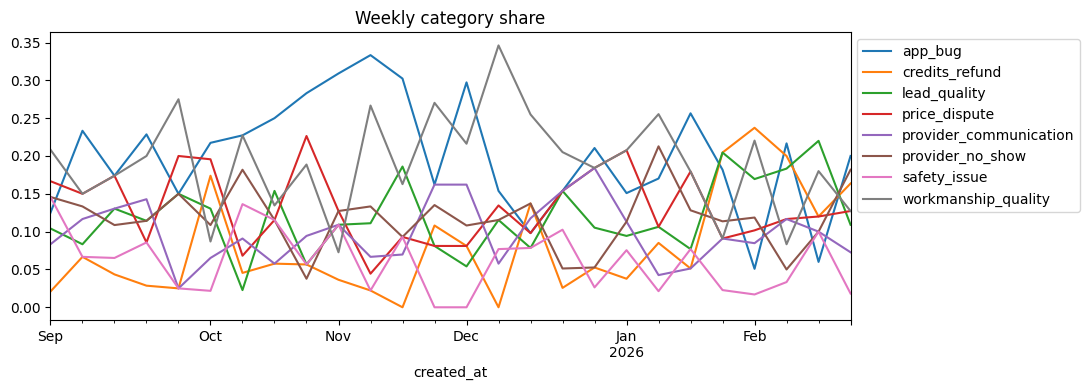

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
counts = pd.read_csv('outputs/project2/weekly_counts.csv', index_col=0, parse_dates=True)
(counts.div(counts.sum(1), axis=0)).plot(figsize=(11,4), title='Weekly category share'); plt.legend(bbox_to_anchor=(1,1)); plt.tight_layout()

In [2]:
pd.read_csv('outputs/project2/emerging_issues.csv')

,category,recent_count,baseline_count,expected_recent,rate_ratio,p_value,emerging
0,credits_refund,41,35,15.0,2.67,0.0000,True
1,lead_quality,38,60,25.6,1.47,0.0130,False
2,price_dispute,26,64,27.3,0.95,0.6249,False
3,provider_no_show,25,62,26.5,0.95,0.6383,False
4,provider_communication,21,54,23.1,0.91,0.6955,False
5,safety_issue,9,27,11.6,0.78,0.8203,False
6,workmanship_quality,34,117,49.8,0.69,0.9924,False
7,app_bug,30,106,45.1,0.67,0.9929,False


In [3]:
pd.read_csv('outputs/project2/priorities.csv', index_col=0)

,share,confidence,rate_ratio,emerging,severity,growth,priority,rank
category,,,,,,,,
credits_refund,0.183,0.872,2.67,True,4,2.67,1.704,1
lead_quality,0.170,0.823,1.47,False,3,1.47,0.616,2
price_dispute,0.116,0.796,0.95,False,4,1.00,0.369,3
provider_no_show,0.112,0.788,0.95,False,4,1.00,0.352,4
app_bug,0.134,0.712,0.67,False,3,1.00,0.286,5
workmanship_quality,0.152,0.851,0.69,False,2,1.00,0.258,6
provider_communication,0.094,0.814,0.91,False,3,1.00,0.229,7
safety_issue,0.040,0.853,0.78,False,5,1.00,0.171,8


### Interpretation
`credits_refund` is flagged as emerging (rate ratio ≈ 2.7, p < 0.001) and rises to the top of the priority list despite not being the most frequent category — severity and growth outweigh raw volume. The output names the owner (finance ops) and the action.

### Decision
This table, plus the redacted examples and the review queue, is the weekly operational deliverable. Monitoring watches category-share drift and the size of the review queue (both in `summary.json`).